# Analisi Qualita' Dati RTP x Supporto GO-LIVE (Tassonomie,Date Scadenza)

Questo notebook esegue una serie di passaggi per identificare la qualità di alcuni campi delle posizioni debitorie GPD.

# Perimetro Dati in analisi
1) Posizioni Debitorie su GPD e ACA (no paCreatePosition)
2) Posizioni Debitore "VALID"
3) Periodo temporale 01/01/2026 -> oggi

In [1]:
import cml.data_v1 as cmldata

In [2]:
CONNECTION_NAME = "dl-analysis-impala-vw"
conn = cmldata.get_connection(CONNECTION_NAME)

In [3]:
## Sample Usage to get pandas data frame
QUERY = """
select t.after.category as category, po.after.description as description, pp.after.id as id, pp.after.iupd as iupd, po.after.due_date as due_date, pp.after.company_name as company_name
from pagopa.silver_gpd_payment_position pp
INNER JOIN pagopa.silver_gpd_payment_option po ON pp.after.id = po.after.payment_position_id
INNER JOIN pagopa.silver_gpd_transfer t ON t.after.payment_option_id = po.after.id
WHERE 
pp.after.inserted_date is not null
and pp.after.inserted_date BETWEEN unix_timestamp('2026-03-01 00:00:01')*1000000 AND unix_timestamp('2026-03-31 00:00:00')*1000000  
and pp.after.status in ('VALID')
and pp.after.iupd not like 'ACA_%' and pp.after.service_type in ('GPD','ACA')
"""

dataframe = conn.get_pandas_dataframe(QUERY)
# Closing the connection
conn.close()

In [4]:
import pandas as pd
import re
import requests
import io
import csv

# --- 1. CARICAMENTO TASSONOMIA (METODO ULTRA-ROBUSTO) ---
url_taxonomy = "https://api.platform.pagopa.it/taxonomy/service/v1/taxonomy?extension=csv"
col_ref = 'dati_specifici_di_incasso'

try:
    headers = {'User-Agent': 'Mozilla/5.0'}
    response = requests.get(url_taxonomy, headers=headers)
    response.raise_for_status()
    
    f = io.StringIO(response.text)
    reader = csv.reader(f, delimiter=';')
    header = next(reader)
    header = [h.replace('"', '').strip() for h in header]
    col_idx = header.index(col_ref)
    
    valid_codes_list = []
    scarti_csv = [] 

    for i, row in enumerate(reader, start=2):
        if len(row) > col_idx:
            raw_code = row[col_idx].replace('"', '').strip()
            if re.match(r'^[6-9]/', raw_code):
                valid_codes_list.append(raw_code)
            else:
                scarti_csv.append({
                    'riga_csv': i,
                    'valore_trovato': raw_code,
                    'note': 'Formato non valido'
                })
        else:
            scarti_csv.append({
                'riga_csv': i,
                'valore_trovato': 'N/D',
                'note': 'Colonna mancante'
            })

    valid_codes_set = set(valid_codes_list)
    
    print(f"--- ANALISI FILE CSV (via URL) ---")
    print(f"Record totali processati:     {len(valid_codes_list) + len(scarti_csv)}")
    print(f"Codici univoci (validi):      {len(valid_codes_set)}")

    # --- STAMPA RIGHE NON VALIDE ---
    if scarti_csv:
        print("\n--- DETTAGLIO RIGHE NON VALIDE ---")
        for scarto in scarti_csv:
            print(f"Riga CSV: {scarto['riga_csv']} | "
                  f"Valore trovato: '{scarto['valore_trovato']}' | "
                  f"Motivo: {scarto['note']}")
    else:
        print("\nNessuna riga non valida trovata.")

except Exception as e:
    print(f"❌ Errore nel caricamento della tassonomia: {e}")
    valid_codes_set = set()


# --- 2. VALIDAZIONE SUL TUO DATAFRAME ---

taxonomic_regex = r'^(9|6|7|8)\/\d{7}(IM|TS|SP|SA|AP)\/?$'
secondary_regex = r'^\d{7}(IM|TS|SP|SA|AP)$'

if 'category' in dataframe.columns:

    # Normalizzazione
    dataframe['category_clean'] = (
        dataframe['category']
        .astype(str)
        .str.replace('"', '')
        .str.strip()
    )

    # A. Validazione Sintattica Principale
    dataframe['is_syntax_correct'] = dataframe['category_clean'].str.match(
        taxonomic_regex, na=False
    )

    # B. Validazione Sintattica Alternativa (7 cifre + suffisso)
    dataframe['is_secondary_syntax'] = dataframe['category_clean'].str.match(
        secondary_regex, na=False
    )

    # C. Validazione Semantica
    dataframe['is_semantically_correct'] = dataframe['category_clean'].isin(valid_codes_set)

    # D. Prefissi specifici (6/7/8)
    dataframe['is_specific_prefix'] = (
        dataframe['is_semantically_correct'] &
        dataframe['category_clean'].str.match(r'^[6-8]/', na=False)
    )

    # --- 3. REPORT GENERALE ---
    total_records = len(dataframe)
    syntax_ok = dataframe['is_syntax_correct'].sum()
    syntax_ko = total_records - syntax_ok

    semantic_ok = dataframe['is_semantically_correct'].sum()
    specific_prefix_ok = dataframe['is_specific_prefix'].sum()

    # --- SOTTO-ANALISI DEI SINTASSI ERRATI ---
    syntax_ko_df = dataframe[~dataframe['is_syntax_correct']]
    secondary_ok = syntax_ko_df['is_secondary_syntax'].sum()
    secondary_ko = syntax_ko - secondary_ok

    print("\n" + "="*95)
    print("📊 REPORT GENERALE ANALISI CODICI TASSONOMICI")
    print("="*95)
    print(f"Totale record analizzati:      {total_records}")
    print(f"1) Rispettano la sintassi:     {syntax_ok} ✅")
    print(f"2) NON rispettano la sintassi: {syntax_ko} ❌")
    print(f"   2.1) Rispettano sintassi alternativa (7 cifre + suffisso): {secondary_ok}")
    print(f"   2.2) NON rispettano neanche la sintassi alternativa:       {secondary_ko}")
    
    if syntax_ko > 0:
        print(f"\n% errori recuperabili con sola aggiunta prefisso: {secondary_ok / syntax_ko:.2%}")

    print(f"\n3) Semanticamente corretti:    {semantic_ok} 🏛️")
    print(f"4) Prefissi Specifici (6/7/8): {specific_prefix_ok} 🏷️")
    print("-" * 95)


    # --- 4. ESEMPI REALI ---
    print("\nDETTAGLIO ESEMPI REALI:")
    casistiche = [
        ("✅ Sintassi OK", dataframe[dataframe['is_syntax_correct']]),
        ("❌ Sintassi Errata", dataframe[~dataframe['is_syntax_correct']]),
        ("🔄 Sintassi Alternativa", dataframe[dataframe['is_secondary_syntax']]),
        ("🏛️ Semantica OK", dataframe[dataframe['is_semantically_correct']]),
        ("🏷️ Prefisso 6/7/8", dataframe[dataframe['is_specific_prefix']])
    ]

    for label, df_sub in casistiche:
        if not df_sub.empty:
            row = df_sub.iloc[0]
            print(f"{label:25} -> Codice: {row['category']:15} | ID: {row['id']:15} | IUPD: {row['iupd']}")
        else:
            print(f"{label:25} -> Nessun record trovato")


    # --- 5. RAGGRUPPAMENTO PER COMPANY_NAME ---
    if 'company_name' in dataframe.columns:
        stats_company = dataframe.groupby('company_name').agg(
            Sintassi_OK=('is_syntax_correct', 'sum'),
            Sintassi_Alt=('is_secondary_syntax', 'sum'),
            Semantica_OK=('is_semantically_correct', 'sum'),
            Prefissi_678=('is_specific_prefix', 'sum'),
            Totale_Record=('category', 'count')
        )

        stats_company['Sintassi_KO'] = stats_company['Totale_Record'] - stats_company['Sintassi_OK']

        stats_company = stats_company[
            ['Sintassi_OK', 'Sintassi_KO', 'Sintassi_Alt',
             'Semantica_OK', 'Prefissi_678', 'Totale_Record']
        ]

        top_50 = stats_company.sort_values(
            by='Totale_Record',
            ascending=False
        ).head(50)

        print("\n" + "="*95)
        print("🏢 STATISTICHE PER COMPANY (Top 50 per volume)")
        print("="*95)
        display(top_50)

        # --- FOCUS DETTAGLIATO PER COMPANY ---
        for company in top_50.index:
            print(f"\n🔍 FOCUS AZIENDA: {company}")
            df_comp = dataframe[dataframe['company_name'] == company]

            casistiche_comp = [
                ("✅ Sintassi OK", df_comp[df_comp['is_syntax_correct']]),
                ("❌ Sintassi Errata", df_comp[~df_comp['is_syntax_correct']]),
                ("🔄 Regex Alternativa OK", df_comp[df_comp['is_secondary_syntax']]),
                ("🚫 Regex Alternativa KO", df_comp[~df_comp['is_secondary_syntax']]),
                ("🏛️ Semantica OK", df_comp[df_comp['is_semantically_correct']]),
                ("🏷️ Prefisso 6/7/8", df_comp[df_comp['is_specific_prefix']])
            ]

            for label, df_sub in casistiche_comp:
                if not df_sub.empty:
                    row = df_sub.iloc[0]
                    print(f"   {label:25} -> Codice: {row['category']:15} | ID: {row['id']:15} | IUPD: {row['iupd']}")
                else:
                    print(f"   {label:25} -> Nessun record trovato")

            print("-" * 80)


    else:
        print("\n⚠️ Colonna 'company_name' non trovata.")

else:
    print("❌ Errore: Colonna 'category' non trovata.")

--- ANALISI FILE CSV (via URL) ---
Record totali processati:     3024
Codici univoci (validi):      3016

--- DETTAGLIO RIGHE NON VALIDE ---
Riga CSV: 2 | Valore trovato: '47' | Motivo: Formato non valido
Riga CSV: 3 | Valore trovato: '47' | Motivo: Formato non valido
Riga CSV: 4 | Valore trovato: '47' | Motivo: Formato non valido
Riga CSV: 5 | Valore trovato: '47' | Motivo: Formato non valido
Riga CSV: 1678 | Valore trovato: '47' | Motivo: Formato non valido
Riga CSV: 1679 | Valore trovato: '47' | Motivo: Formato non valido
Riga CSV: 1680 | Valore trovato: '47' | Motivo: Formato non valido
Riga CSV: 1681 | Valore trovato: '47' | Motivo: Formato non valido

📊 REPORT GENERALE ANALISI CODICI TASSONOMICI
Totale record analizzati:      935446
1) Rispettano la sintassi:     673088 ✅
2) NON rispettano la sintassi: 262358 ❌
   2.1) Rispettano sintassi alternativa (7 cifre + suffisso): 196865
   2.2) NON rispettano neanche la sintassi alternativa:       65493

% errori recuperabili con sola ag

,Sintassi_OK,Sintassi_KO,Sintassi_Alt,Semantica_OK,Prefissi_678,Totale_Record
company_name,,,,,,
Sorit S.p.A.,80153,0,0,80153,80153,80153
Ge.Fi.L. Spa - Gestione Fiscalita' Locale,51134,0,0,51134,51134,51134
Comune di Ferrara,38396,1,0,38396,0,38397
ATER DELLA PROVINCIA DI ROMA,19240,0,0,19240,0,19240
COMUNE DI FIRENZE,17216,0,0,17216,0,17216
Comune di Bologna,17060,0,0,17044,0,17060
MINISTERO DELL'ECONOMIA E DELLE FINANZE,13,14926,0,13,0,14939
Comune di Palestrina,14885,3,0,14868,0,14888
AREA S.R.L.,11386,0,0,11379,0,11386



🔍 FOCUS AZIENDA: Sorit S.p.A.
   ✅ Sintassi OK             -> Codice: 6/0115107AP/    | ID:       294606219 | IUPD: 02241250394-5ea9e489-8dd7-4926-9bec-2f1c02f9c05c
   ❌ Sintassi Errata         -> Nessun record trovato
   🔄 Regex Alternativa OK    -> Nessun record trovato
   🚫 Regex Alternativa KO    -> Codice: 6/0115107AP/    | ID:       294606219 | IUPD: 02241250394-5ea9e489-8dd7-4926-9bec-2f1c02f9c05c
   🏛️ Semantica OK           -> Codice: 6/0115107AP/    | ID:       294606219 | IUPD: 02241250394-5ea9e489-8dd7-4926-9bec-2f1c02f9c05c
   🏷️ Prefisso 6/7/8         -> Codice: 6/0115107AP/    | ID:       294606219 | IUPD: 02241250394-5ea9e489-8dd7-4926-9bec-2f1c02f9c05c
--------------------------------------------------------------------------------

🔍 FOCUS AZIENDA: Ge.Fi.L. Spa - Gestione Fiscalita' Locale
   ✅ Sintassi OK             -> Codice: 6/0115107AP/    | ID:       294704028 | IUPD: 01240080117-3b606198-c165-4464-b6a1-a15db43f98b4
   ❌ Sintassi Errata         -> Nessun record

In [10]:
import pandas as pd
import re
import requests
import io
import csv

# --- 1. CARICAMENTO TASSONOMIA (METODO ULTRA-ROBUSTO) ---
url_taxonomy = "https://api.platform.pagopa.it/taxonomy/service/v1/taxonomy?extension=csv"
col_ref = 'dati_specifici_di_incasso'

try:
    headers = {'User-Agent': 'Mozilla/5.0'}
    response = requests.get(url_taxonomy, headers=headers)
    response.raise_for_status()
    
    f = io.StringIO(response.text)
    reader = csv.reader(f, delimiter=';')
    header = next(reader)
    header = [h.replace('"', '').strip() for h in header]
    col_idx = header.index(col_ref)
    
    valid_codes_list = []
    scarti_csv = [] 

    for i, row in enumerate(reader, start=2):
        if len(row) > col_idx:
            raw_code = row[col_idx].replace('"', '').strip()
            if re.match(r'^[6-9]/', raw_code):
                valid_codes_list.append(raw_code)
            else:
                scarti_csv.append({
                    'riga_csv': i,
                    'valore_trovato': raw_code,
                    'note': 'Formato non valido'
                })
        else:
            scarti_csv.append({
                'riga_csv': i,
                'valore_trovato': 'N/D',
                'note': 'Colonna mancante'
            })

    valid_codes_set = set(valid_codes_list)
    
    print(f"--- ANALISI FILE CSV (via URL) ---")
    print(f"Record totali processati:      {len(valid_codes_list) + len(scarti_csv)}")
    print(f"Codici univoci (validi):       {len(valid_codes_set)}")

except Exception as e:
    print(f"❌ Errore nel caricamento della tassonomia: {e}")
    valid_codes_set = set()


# --- 2. VALIDAZIONE SUL TUO DATAFRAME ---

taxonomic_regex = r'^(9|6|7|8)\/\d{7}(IM|TS|SP|SA|AP)\/?$'
secondary_regex = r'^\d{7}(IM|TS|SP|SA|AP)$'

if 'category' in dataframe.columns:

    # Normalizzazione
    dataframe['category_clean'] = (
        dataframe['category']
        .astype(str)
        .str.replace('"', '')
        .str.strip()
    )

    # A. Validazione Sintattica Principale
    dataframe['is_syntax_correct'] = dataframe['category_clean'].str.match(
        taxonomic_regex, na=False
    )

    # B. Validazione Sintattica Alternativa (7 cifre + suffisso)
    dataframe['is_secondary_syntax'] = dataframe['category_clean'].str.match(
        secondary_regex, na=False
    )

    # C. Validazione Semantica
    dataframe['is_semantically_correct'] = dataframe['category_clean'].isin(valid_codes_set)

    # D. Prefissi specifici (6/7/8)
    dataframe['is_specific_prefix'] = (
        dataframe['is_semantically_correct'] &
        dataframe['category_clean'].str.match(r'^[6-8]/', na=False)
    )

    # --- 3. REPORT GENERALE ---
    total_records = len(dataframe)
    syntax_ok = dataframe['is_syntax_correct'].sum()
    syntax_ko = total_records - syntax_ok
    semantic_ok = dataframe['is_semantically_correct'].sum()
    specific_prefix_ok = dataframe['is_specific_prefix'].sum()

    print("\n" + "="*95)
    print("📊 REPORT GENERALE ANALISI CODICI TASSONOMICI")
    print("="*95)
    print(f"Totale record analizzati:      {total_records}")
    print(f"1) Rispettano la sintassi:     {syntax_ok} ✅")
    print(f"2) NON rispettano la sintassi: {syntax_ko} ❌")
    
    if syntax_ko > 0:
        syntax_ko_df = dataframe[~dataframe['is_syntax_correct']]
        secondary_ok = syntax_ko_df['is_secondary_syntax'].sum()
        print(f"   2.1) Recuperabili con prefisso: {secondary_ok}")
        print(f"\n% errori recuperabili: {secondary_ok / syntax_ko:.2%}")

    print(f"\n3) Semanticamente corretti:    {semantic_ok} 🏛️")
    print(f"4) Prefissi Specifici (6/7/8): {specific_prefix_ok} 🏷️")
    print("-" * 95)


    # --- 4. ESEMPI REALI ---
    print("\nDETTAGLIO ESEMPI REALI:")
    casistiche = [
        ("✅ Sintassi OK", dataframe[dataframe['is_syntax_correct']]),
        ("❌ Sintassi Errata", dataframe[~dataframe['is_syntax_correct']]),
        ("🏛️ Semantica OK", dataframe[dataframe['is_semantically_correct']]),
        ("🏷️ Prefisso 6/7/8", dataframe[dataframe['is_specific_prefix']])
    ]

    for label, df_sub in casistiche:
        if not df_sub.empty:
            row = df_sub.iloc[0]
            # Usiamo .get() per evitare errori se le colonne id/iupd mancano
            v_id = row.get('id', 'N/D')
            v_iupd = row.get('iupd', 'N/D')
            print(f"{label:25} -> Codice: {row['category']:15} | ID: {v_id:15} | IUPD: {v_iupd}")
        else:
            print(f"{label:25} -> Nessun record trovato")


    # --- 5. RAGGRUPPAMENTO PER COMPANY_NAME ---
    if 'company_name' in dataframe.columns:
        stats_company = dataframe.groupby('company_name').agg(
            Sintassi_OK=('is_syntax_correct', 'sum'),
            Sintassi_Alt=('is_secondary_syntax', 'sum'),
            Semantica_OK=('is_semantically_correct', 'sum'),
            Prefissi_678=('is_specific_prefix', 'sum'),
            Totale_Record=('category', 'count')
        )
        stats_company['Sintassi_KO'] = stats_company['Totale_Record'] - stats_company['Sintassi_OK']
        
        top_50 = stats_company.sort_values(by='Totale_Record', ascending=False).head(50)

        print("\n" + "="*95)
        print("🏢 STATISTICHE PER COMPANY (Top 50 per volume)")
        print("="*95)
        display(top_50)

        # --- 6. FOCUS DETTAGLIATO PER PREFISSI 6/7/8 ---
        print("\n" + "="*95)
        print("🏷️ DETTAGLIO CODICI PREFISSO 6/7/8 PER AZIENDA")
        print("="*95)

        df_678 = dataframe[dataframe['is_specific_prefix']].copy()

        if df_678.empty:
            print("⚠️ Nessun record con prefisso 6/7/8 valido trovato.")
        else:
            stats_678 = df_678.groupby('company_name').agg(
                Totale_Codici_678=('category_clean', 'count'),
                Codici_Univoci=('category_clean', 'nunique')
            ).sort_values('Totale_Codici_678', ascending=False)

            for company in stats_678.index:
                row_stats = stats_678.loc[company]
                print(f"\n🏢 {company} [{row_stats['Totale_Codici_678']} record | {row_stats['Codici_Univoci']} univoci]")
                
                # Sottodettaglio dei codici usati da questa specifica azienda
                dettaglio_codici = (
                    df_678[df_678['company_name'] == company]['category_clean']
                    .value_counts()
                    .reset_index()
                )
                dettaglio_codici.columns = ['Codice', 'Occorrenze']
                
                for _, r in dettaglio_codici.iterrows():
                    print(f"   - {r['Codice']:<25} ({r['Occorrenze']} occorrenze)")
                print("-" * 50)
    else:
        print("\n⚠️ Colonna 'company_name' non trovata.")

else:
    print("❌ Errore: Colonna 'category' non trovata.")

--- ANALISI FILE CSV (via URL) ---
Record totali processati:      3024
Codici univoci (validi):       3016

📊 REPORT GENERALE ANALISI CODICI TASSONOMICI
Totale record analizzati:      349724
1) Rispettano la sintassi:     236784 ✅
2) NON rispettano la sintassi: 112940 ❌
   2.1) Recuperabili con prefisso: 87131

% errori recuperabili: 77.15%

3) Semanticamente corretti:    217463 🏛️
4) Prefissi Specifici (6/7/8): 35752 🏷️
-----------------------------------------------------------------------------------------------

DETTAGLIO ESEMPI REALI:
✅ Sintassi OK             -> Codice: 9/0102100SA/    | ID:       294334640 | IUPD: EASYPAI_ACIC6_82007930637_00012606200011456
❌ Sintassi Errata         -> Codice: 0801100AP       | ID:       294335357 | IUPD: 04135310482_f779e4df-b12c-4845-ba71-e7a08647390a
🏛️ Semantica OK           -> Codice: 9/0102100SA/    | ID:       294334640 | IUPD: EASYPAI_ACIC6_82007930637_00012606200011456
🏷️ Prefisso 6/7/8         -> Codice: 6/0115107AP/    | ID:       293

,Sintassi_OK,Sintassi_Alt,Semantica_OK,Prefissi_678,Totale_Record,Sintassi_KO
company_name,,,,,,
Comune di Ferrara,16916,0,16916,0,16916,0
Comune di Bologna,12238,0,12230,0,12238,0
ARCA PUGLIA CENTRALE,10395,0,10395,0,10395,0
MINISTERO DELL'ECONOMIA E DELLE FINANZE,2,0,2,0,9502,9500
Comune di Verona,8002,918,8002,8002,8920,918
Provincia di Asti,8552,0,8552,8552,8552,0
Comune di Orsomarso,8470,0,4235,0,8470,0
OPI di GENOVA,7891,0,7891,0,7891,0
Comune di Catenanuova,6938,0,6930,0,6938,0



🏷️ DETTAGLIO CODICI PREFISSO 6/7/8 PER AZIENDA

🏢 Provincia di Asti [8552 record | 1 univoci]
   - 6/0201139AP/              (8552 occorrenze)
--------------------------------------------------

🏢 Comune di Verona [8002 record | 14 univoci]
   - 6/0102100SA/              (7865 occorrenze)
   - 6/0104103SP/              (52 occorrenze)
   - 6/0105107TS/              (50 occorrenze)
   - 6/0111100TS/              (8 occorrenze)
   - 6/0104101TS/              (6 occorrenze)
   - 6/0101106SA/              (6 occorrenze)
   - 6/0101103IM/              (5 occorrenze)
   - 6/0105101TS/              (3 occorrenze)
   - 6/0102102SP/              (2 occorrenze)
   - 6/0115105AP/              (1 occorrenze)
   - 6/0105102TS/              (1 occorrenze)
   - 6/0108104AP/              (1 occorrenze)
   - 6/0105100SP/              (1 occorrenze)
   - 6/0108101SP/              (1 occorrenze)
--------------------------------------------------

🏢 Comune di Campli [5090 record | 1 univoci]
   - 6/01151

## Analisi lunghezza causali

> 1 e <= 30 caratteri: 102163 record (29.21%)
> 30 e <= 50 caratteri: 146927 record (42.01%)
> 50 e <= 70 caratteri: 57955 record (16.57%)
> 70 e <= 100 caratteri: 15278 record (4.37%)
> 100 e <= 140 caratteri: 2835 record (0.81%)
> 140 caratteri: 0 record (0.00%)


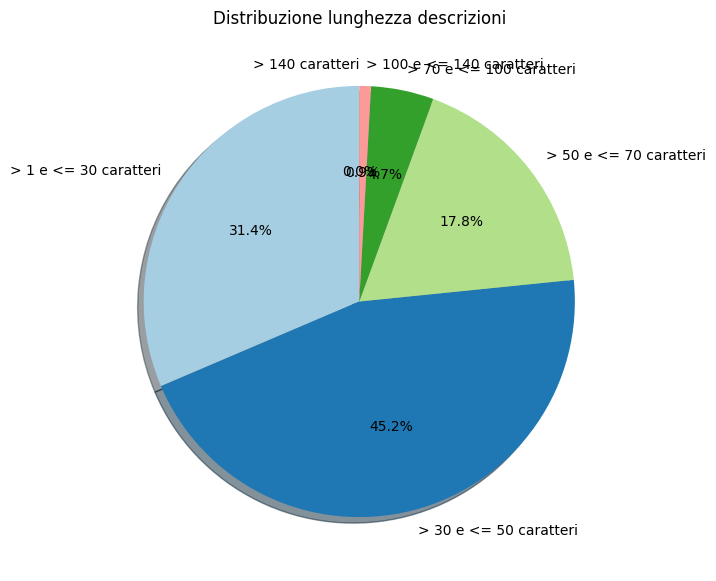

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

def analyze_description_length(df):
    
    # Definizione delle categorie di lunghezza
    bins = [(1, 30), (31, 50), (51, 70), (71, 100), (101, 140), (141, float('inf'))]
    labels = ["> 1 e <= 30 caratteri", "> 30 e <= 50 caratteri", "> 50 e <= 70 caratteri", "> 70 e <= 100 caratteri", "> 100 e <= 140 caratteri", "> 140 caratteri"]
    
    total = len(df)
    counts = []
    percentages = []
    
    # Calcola il numero di record per ogni categoria
    for low, high in bins:
        count = len(df[(df['description'].str.len() > low) & (df['description'].str.len() <= high)])
        percentage = (count / total) * 100 if total > 0 else 0
        counts.append(count)
        percentages.append(percentage)
    
    # Stampa i risultati
    for label, count, percentage in zip(labels, counts, percentages):
        print(f"{label}: {count} record ({percentage:.2f}%)")
    
    if total == 0:
        print("Nessun record presente nel dataset. Diagramma a torta non generato.")
        return
    
    # Crea il diagramma a torta
    plt.figure(figsize=(7,7))
    plt.pie(counts, labels=labels, autopct='%1.1f%%', colors=plt.cm.Paired.colors, shadow=True, startangle=90)
    plt.title('Distribuzione lunghezza descrizioni')
    plt.show()

analyze_description_length(dataframe)

## Analisi Date Scadenza

Elaborazione record: 100%|██████████| 349724/349724 [00:22<00:00, 15487.38it/s]



--- ANALISI CLUSTER TEMPORALI ---
Entro 1 anno: 67673 record (19.35%)
Tra 1 e 2 anni: 17462 record (4.99%)
Tra 2 e 10 anni: 17499 record (5.00%)
Tra 10 e 20 anni: 89 record (0.03%)
Tra 20 e 30 anni: 24 record (0.01%)
Oltre 30 anni: 244702 record (69.97%)


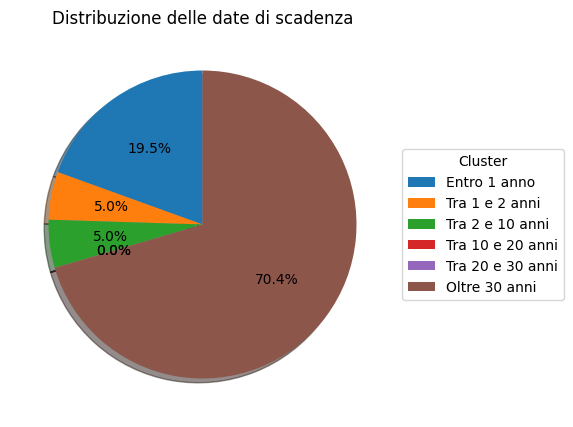


--- TOP 50 COMPANY PER CLUSTER ---

🔎 CLUSTER: Entro 1 anno
1. Comune di Catenanuova: 6930 record
2. Saie: 3570 record
3. Veneziana Energia Risorse Idriche Territorio Ambiente Servizi S.P.A.: 3196 record
4. Ministero dell'Ambiente e della Sicurezza Energetica: 2106 record
5. Comune di Acireale: 1952 record
6. Ordine delle Professioni Infermieristiche di Rieti: 1695 record
7. Comune di Bondeno: 1679 record
8. ASL Napoli 1 Centro: 1420 record
9. Alperia Smart Services Srl: 1363 record
10. ASL Salerno: 1320 record
11. A.S.D. T.M.A. Group Italia: 1234 record
12. Azienda Sanitaria Locale BARI: 1211 record
13. Azienda Ospedale - Universita' Padova: 1055 record
14. Regione del Veneto: 1043 record
15. ASL Napoli 3 Sud: 1035 record
16. ASL Napoli 2 Nord: 1025 record
17. AOU Federico II: 1012 record
18. ASL Caserta: 987 record
19. SOCIETA' COOPERATIVA SOCIALE GIALLA: 937 record
20. Comune di Dugenta: 899 record
21. Ordine Med. Chirur. E Odont. Prov. Cagliari: 850 record
22. Elettrotecnica C.Lux

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta, timezone
from tqdm import tqdm
from collections import Counter

def analyze_due_dates(df):
    total = len(df)
    if total == 0:
        print("Nessun record presente nel dataset.")
        return
    
    if 'due_date' not in df.columns:
        print("Colonna 'due_date' non presente.")
        return

    today = datetime.now(timezone.utc)

    # ⚠️ Cluster ORDINATI e MUTUALMENTE ESCLUSIVI
    clusters = [
        ("Entro 1 anno", 1),
        ("Tra 1 e 2 anni", 2),
        ("Tra 2 e 10 anni", 10),
        ("Tra 10 e 20 anni", 20),
        ("Tra 20 e 30 anni", 30),
        ("Oltre 30 anni", float("inf"))
    ]

    # struttura: {cluster: {"dates": [], "companies": []}}
    cluster_data = {
        name: {"dates": [], "companies": []}
        for name, _ in clusters
    }

    df_filtered = df.dropna(subset=['due_date'])

    for _, row in tqdm(df_filtered.iterrows(), total=len(df_filtered), desc="Elaborazione record"):
        try:
            date_val = row['due_date']
            company = row.get('company_name', 'UNKNOWN')

            timestamp_seconds = date_val / 1_000_000
            date_converted = datetime.fromtimestamp(timestamp_seconds, tz=timezone.utc)

            delta_years = (date_converted - today).total_seconds() / (365 * 24 * 3600)

            lower_bound = 0
            for name, upper_bound in clusters:
                if lower_bound < delta_years <= upper_bound:
                    cluster_data[name]["dates"].append(date_converted.strftime("%d/%m/%Y"))
                    cluster_data[name]["companies"].append(company)
                    break
                lower_bound = upper_bound

        except Exception:
            continue

    # ==========================
    # 1️⃣ ANALISI CLUSTER
    # ==========================
    print("\n--- ANALISI CLUSTER TEMPORALI ---")
    for name, data in cluster_data.items():
        count = len(data["dates"])
        perc = (count / total * 100) if total else 0
        print(f"{name}: {count} record ({perc:.2f}%)")

    # ==========================
    # 2️⃣ GRAFICO
    # ==========================
    plt.figure(figsize=(8, 5))
    counts = [len(cluster_data[name]["dates"]) for name, _ in clusters]
    labels = [name for name, _ in clusters]

    plt.pie(counts, autopct='%1.1f%%', shadow=True, startangle=90)
    plt.legend(labels, title="Cluster", loc="center left", bbox_to_anchor=(1, 0.5))
    plt.title("Distribuzione delle date di scadenza")
    plt.subplots_adjust(right=0.7)
    plt.show()

    # ==========================
    # 3️⃣ TOP 50 COMPANY PER OGNI CLUSTER
    # ==========================
    print("\n--- TOP 50 COMPANY PER CLUSTER ---")

    for name in cluster_data.keys():
        companies = cluster_data[name]["companies"]

        print(f"\n🔎 CLUSTER: {name}")
        
        if companies:
            top_50 = Counter(companies).most_common(50)
            for i, (company, count) in enumerate(top_50, 1):
                print(f"{i}. {company}: {count} record")
        else:
            print("Nessun record in questo cluster.")


# Esecuzione
analyze_due_dates(dataframe)

In [13]:
import pandas as pd
import re
import requests
import io
import csv

# ==========================================================
# 1️⃣ CARICAMENTO TASSONOMIA
# ==========================================================

url_taxonomy = "https://api.platform.pagopa.it/taxonomy/service/v1/taxonomy?extension=csv"
col_ref = 'dati_specifici_di_incasso'

try:
    headers = {'User-Agent': 'Mozilla/5.0'}
    response = requests.get(url_taxonomy, headers=headers)
    response.raise_for_status()
    
    f = io.StringIO(response.text)
    reader = csv.reader(f, delimiter=';')
    header = next(reader)
    header = [h.replace('"', '').strip() for h in header]
    col_idx = header.index(col_ref)
    
    valid_codes_list = []
    scarti_csv = []

    for i, row in enumerate(reader, start=2):
        if len(row) > col_idx:
            raw_code = row[col_idx].replace('"', '').strip()
            if re.match(r'^[6-9]/', raw_code):
                valid_codes_list.append(raw_code)
            else:
                scarti_csv.append({
                    'riga_csv': i,
                    'valore_trovato': raw_code,
                    'note': 'Formato non valido'
                })
        else:
            scarti_csv.append({
                'riga_csv': i,
                'valore_trovato': 'N/D',
                'note': 'Colonna mancante'
            })

    valid_codes_set = set(valid_codes_list)

    print("="*95)
    print("📂 ANALISI FILE TASSONOMIA")
    print("="*95)
    print(f"Record totali processati:      {len(valid_codes_list) + len(scarti_csv)}")
    print(f"Codici univoci validi:         {len(valid_codes_set)}")
    print(f"Righe scartate:                {len(scarti_csv)}")

except Exception as e:
    print(f"❌ Errore nel caricamento della tassonomia: {e}")
    valid_codes_set = set()

# ==========================================================
# 2️⃣ VALIDAZIONE DATAFRAME PRINCIPALE
# ==========================================================

taxonomic_regex = r'^(9|6|7|8)\/\d{7}(IM|TS|SP|SA|AP)\/?$'
secondary_regex = r'^\d{7}(IM|TS|SP|SA|AP)$'

if 'category' in dataframe.columns:

    dataframe['category_clean'] = (
        dataframe['category']
        .astype(str)
        .str.replace('"', '')
        .str.strip()
    )

    # Validazione sintattica principale
    dataframe['is_syntax_correct'] = dataframe['category_clean'].str.match(
        taxonomic_regex, na=False
    )

    # Sintassi alternativa
    dataframe['is_secondary_syntax'] = dataframe['category_clean'].str.match(
        secondary_regex, na=False
    )

    # Validazione semantica
    dataframe['is_semantically_correct'] = dataframe['category_clean'].isin(valid_codes_set)

    # Prefisso 6/7/8 (semanticamente valido)
    dataframe['is_specific_prefix'] = (
        dataframe['is_semantically_correct'] &
        dataframe['category_clean'].str.match(r'^[6-8]/', na=False)
    )

    # ==========================================================
    # 3️⃣ REPORT GENERALE
    # ==========================================================

    total_records = len(dataframe)
    syntax_ok = dataframe['is_syntax_correct'].sum()
    semantic_ok = dataframe['is_semantically_correct'].sum()
    specific_prefix_ok = dataframe['is_specific_prefix'].sum()

    print("\n" + "="*95)
    print("📊 REPORT GENERALE ANALISI CODICI TASSONOMICI")
    print("="*95)
    print(f"Totale record analizzati:      {total_records}")
    print(f"Sintatticamente validi:        {syntax_ok}")
    print(f"Semanticamente validi:         {semantic_ok}")
    print(f"Prefisso 6/7/8 validi:         {specific_prefix_ok}")
    print("-" * 95)

    # ==========================================================
    # 4️⃣ ESEMPI REALI
    # ==========================================================

    print("\n🔎 ESEMPI REALI")

    casistiche = [
        ("✅ Sintassi OK", dataframe[dataframe['is_syntax_correct']]),
        ("❌ Sintassi Errata", dataframe[~dataframe['is_syntax_correct']]),
        ("🏛️ Semantica OK", dataframe[dataframe['is_semantically_correct']]),
        ("🏷️ Prefisso 6/7/8", dataframe[dataframe['is_specific_prefix']])
    ]

    for label, df_sub in casistiche:
        if not df_sub.empty:
            row = df_sub.iloc[0]
            v_id = row.get('id', 'N/D')
            v_iupd = row.get('iupd', 'N/D')
            print(f"{label:25} -> Codice: {row['category']:15} | ID: {v_id} | IUPD: {v_iupd}")
        else:
            print(f"{label:25} -> Nessun record trovato")

    # ==========================================================
    # 5️⃣ REPORT TOP 50 COMPANY
    # ==========================================================

    if 'company_name' in dataframe.columns:

        df_valid = dataframe[dataframe['is_semantically_correct']].copy()

        if df_valid.empty:
            print("\n⚠️ Nessun record semanticamente valido trovato.")
        else:

            stats_company = df_valid.groupby('company_name').agg(
                Record_Sintassi_OK=('is_syntax_correct', 'sum'),
                Record_Semantica_OK=('is_semantically_correct', 'sum'),
                Record_Prefisso_678=('is_specific_prefix', 'sum')
            )

            stats_company['%_Prefisso_678_su_Semantica'] = (
                stats_company['Record_Prefisso_678'] /
                stats_company['Record_Semantica_OK']
            ).fillna(0) * 100

            top_50 = (
                stats_company
                .sort_values(by='Record_Semantica_OK', ascending=False)
                .head(50)
            )

            print("\n" + "="*110)
            print("🏢 REPORT TOP 50 COMPANY")
            print("="*110)

            display(top_50)

            print("\n--- DETTAGLIO TESTUALE ---")

            for company, row in top_50.iterrows():
                print(f"\n🏢 {company}")
                print(f"   • Sintatticamente validi:   {int(row['Record_Sintassi_OK'])}")
                print(f"   • Semanticamente validi:    {int(row['Record_Semantica_OK'])}")
                print(f"   • Prefisso 6/7/8:           {int(row['Record_Prefisso_678'])}")
                print(f"   • % Prefisso 6/7/8:         {row['%_Prefisso_678_su_totali']:.2f}%")
                print("-" * 60)

    else:
        print("\n⚠️ Colonna 'company_name' non trovata.")

else:
    print("❌ Errore: Colonna 'category' non trovata.")

📂 ANALISI FILE TASSONOMIA
Record totali processati:      3024
Codici univoci validi:         3016
Righe scartate:                8

📊 REPORT GENERALE ANALISI CODICI TASSONOMICI
Totale record analizzati:      349724
Sintatticamente validi:        236784
Semanticamente validi:         217463
Prefisso 6/7/8 validi:         35752
-----------------------------------------------------------------------------------------------

🔎 ESEMPI REALI
✅ Sintassi OK             -> Codice: 9/0102100SA/    | ID: 294334640 | IUPD: EASYPAI_ACIC6_82007930637_00012606200011456
❌ Sintassi Errata         -> Codice: 0801100AP       | ID: 294335357 | IUPD: 04135310482_f779e4df-b12c-4845-ba71-e7a08647390a
🏛️ Semantica OK           -> Codice: 9/0102100SA/    | ID: 294334640 | IUPD: EASYPAI_ACIC6_82007930637_00012606200011456
🏷️ Prefisso 6/7/8         -> Codice: 6/0115107AP/    | ID: 293936333 | IUPD: 80005970670-61199bf6-0d4b-4289-99f6-f4e6080d7769

🏢 REPORT TOP 50 COMPANY


,Record_Sintassi_OK,Record_Semantica_OK,Record_Prefisso_678,%_Prefisso_678_su_Semantica
company_name,,,,
Comune di Ferrara,16916,16916,0,0.000000
Comune di Bologna,12230,12230,0,0.000000
ARCA PUGLIA CENTRALE,10395,10395,0,0.000000
Provincia di Asti,8552,8552,8552,100.000000
Comune di Verona,8002,8002,8002,100.000000
OPI di GENOVA,7891,7891,0,0.000000
Comune di Catenanuova,6930,6930,0,0.000000
OPI DI CATANIA,6661,6661,0,0.000000
Sinergas S.p.A.,6410,6410,0,0.000000



--- DETTAGLIO TESTUALE ---

🏢 Comune di Ferrara
   • Sintatticamente validi:   16916
   • Semanticamente validi:    16916
   • Prefisso 6/7/8:           0
   • % Prefisso 6/7/8:         0.00%
------------------------------------------------------------

🏢 Comune di Bologna
   • Sintatticamente validi:   12230
   • Semanticamente validi:    12230
   • Prefisso 6/7/8:           0
   • % Prefisso 6/7/8:         0.00%
------------------------------------------------------------

🏢 ARCA PUGLIA CENTRALE
   • Sintatticamente validi:   10395
   • Semanticamente validi:    10395
   • Prefisso 6/7/8:           0
   • % Prefisso 6/7/8:         0.00%
------------------------------------------------------------

🏢 Provincia di Asti
   • Sintatticamente validi:   8552
   • Semanticamente validi:    8552
   • Prefisso 6/7/8:           8552
   • % Prefisso 6/7/8:         100.00%
------------------------------------------------------------

🏢 Comune di Verona
   • Sintatticamente validi:   8002
   • S